# **Preprocesamiento y Entrenamiento con datos tabulares**

# Parte 1: Preprocesamiento

## Consumir a un archivo en Google Drive

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importar Datos

In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/IAA/data/weather_curico_2025.csv", sep=",", index_col=[0])
df

,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,shortwave_radiation,apparent_temperature,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition
date,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,25.85,27.896322,0.0,0.0,0.0,11.734564,0.0,1012.6,1.0,2.403094,54.0,23.113243,0.152023,29.90,0.133,Sunny
2025-01-01 01:00:00+00:00,24.10,26.748075,0.0,0.0,0.0,14.019216,0.0,1013.0,0.0,2.199991,0.0,20.591618,0.155194,28.70,0.130,Sunny
2025-01-01 02:00:00+00:00,22.50,25.476387,0.0,0.0,0.0,13.929953,0.0,1013.7,0.0,2.032472,0.0,18.628262,0.150560,27.10,0.130,Sunny
2025-01-01 03:00:00+00:00,21.10,25.921600,0.0,0.0,0.0,13.080687,0.0,1014.1,0.0,1.855032,0.0,17.193653,0.135994,25.70,0.130,Sunny
2025-01-01 04:00:00+00:00,20.05,27.258875,0.0,0.0,0.0,13.433838,0.0,1013.9,0.0,1.707537,0.0,16.060156,0.132148,24.40,0.130,Sunny
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00+00:00,35.10,19.553830,0.0,0.0,0.0,6.109403,0.0,1010.8,1.0,4.547739,978.0,36.449640,0.776743,38.65,0.117,Sunny
2025-12-31 20:00:00+00:00,35.35,19.548050,0.0,0.0,0.0,9.847496,0.0,1010.3,1.0,4.611172,844.0,35.256462,0.713698,39.25,0.117,Sunny
2025-12-31 21:00:00+00:00,33.85,24.541935,0.0,0.0,0.0,15.158522,0.0,1010.0,1.0,3.979631,664.0,32.484528,0.615473,38.85,0.117,Sunny


## Importar librerías

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer
from scipy.stats import chi2_contingency

## Tareas del Preprocesamiento


Vamos a realizar las siguientes tareas de procesamiento:

1. **Analizar outliers**  
   Identificaremos y trataremos valores atípicos que puedan afectar el modelo.

2. **Transformar variables**  
   Aplicaremos conversiones necesarias a los  datos.

3. **Generar variables adicionales**  
   Crearemos nuevas características derivadas que puedan mejorar el análisis.

4. **Transformación matemática**  
   Aquellas variables categóricas deben transformarse en valores que puedan manejarse en modelos, es decir, en números.

5. **Normalizar datos**  
   Normalizaremos las escalas de las variables para comparaciones consistentes.

5. **Selección de variables**  
   No todas las variables son útiles, por lo que es necesario descartar aquellas que no aportan nada.

### Analizar outliers

**Consideraciones para el tratamiento de valores atípicos/faltantes:**

1. **Cantidad < 5%**  
   - Variables numéricas: reemplazar por la media  
   - Variables categóricas: reemplazar por la moda  

2. **Cantidad entre 5% y 50%**  
   - Requiere técnicas de imputación múltiple (pueden utilizarse librerías especializadas)  

3. **Cantidad > 50%**  
   - La columna debe ser descartada  

**Nota importante:** Estos porcentajes son reglas generales y pueden variar según el caso específico.

#### General

In [ ]:
df.describe(include='all').round(1)

,result,num_word_text,count_dialogue_captador,count_dialogue_cliente,sentiment_text,sentiment_captador,sentiment_cliente,num_word_text_captador,num_word_text_cliente
count,6568.0,6568.0,6568.0,6568.0,6568,6568,6568,6568.0,6568.0
unique,NaN,NaN,NaN,NaN,3,3,3,NaN,NaN
top,NaN,NaN,NaN,NaN,NEU,NEU,NEU,NaN,NaN
freq,NaN,NaN,NaN,NaN,3880,3947,5331,NaN,NaN
mean,0.9,425.8,11.9,11.8,NaN,NaN,NaN,316.2,76.8
std,0.3,175.3,4.8,5.0,NaN,NaN,NaN,113.7,84.2
min,0.0,132.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0
25%,1.0,323.0,9.0,9.0,NaN,NaN,NaN,246.0,32.0
50%,1.0,389.0,11.0,11.0,NaN,NaN,NaN,301.0,51.0
75%,1.0,479.0,14.0,13.0,NaN,NaN,NaN,362.0,90.0


En este caso es poco probable que falten valores, ya que nosotros mismos creamos la base de datos; sin embargo, es importante revisarlo en caso de que obtengan los datos de alguna fuente externa.

#### Variable: num_word_text

In [ ]:
var_check = 'num_word_text'

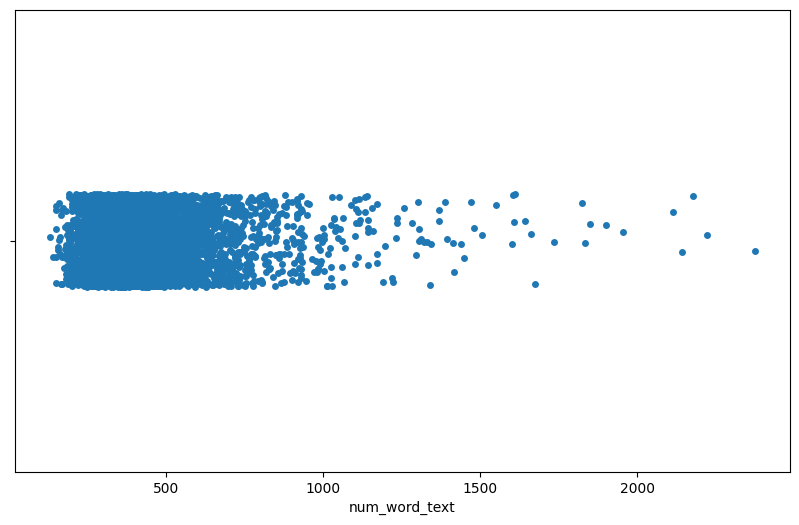

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

In [ ]:
df.loc[df[var_check] > 1500, [var_check]] = np.nan
nan_percentage = df[var_check].isna().sum() / len(df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en num_word_text: 0.30%


In [ ]:
df[var_check] = df[var_check].fillna(df[var_check].median())

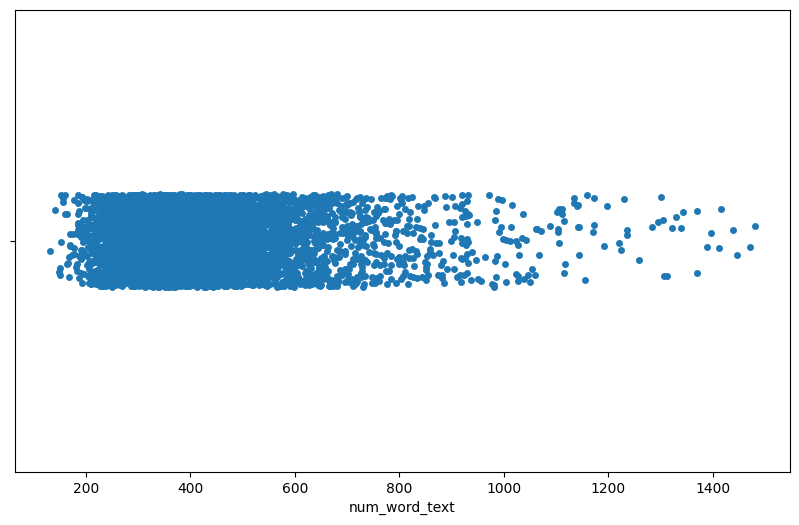

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

Como se puede ver, acotamos los valores para buscar y reemplazar aquellos que estén más alejados. Es importante revisar la cantidad de datos que estamos quitando, pues fácilmente podemos eliminar un conjunto muy grande. Esto es algo arbitrario; sin embargo, existen enfoques más sofisticados que se escapan de lo que se pretende explicar.

#### Variable: count_dialogue_captador

In [ ]:
var_check = 'count_dialogue_captador'

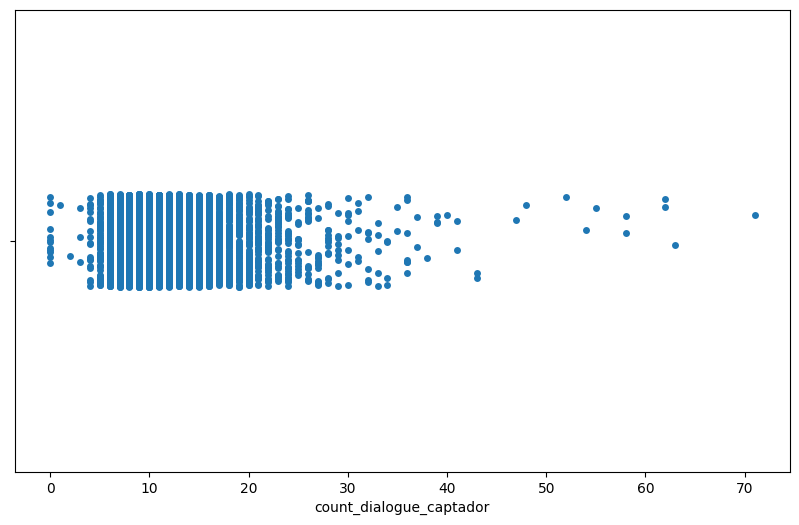

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

In [ ]:
df.loc[df[var_check] > 40, [var_check]] = np.nan
df.loc[df[var_check] < 4, [var_check]] = np.nan
nan_percentage = df[var_check].isna().sum() / len(df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en count_dialogue_captador: 0.49%


In [ ]:
df[var_check] = df[var_check].fillna(df[var_check].median())

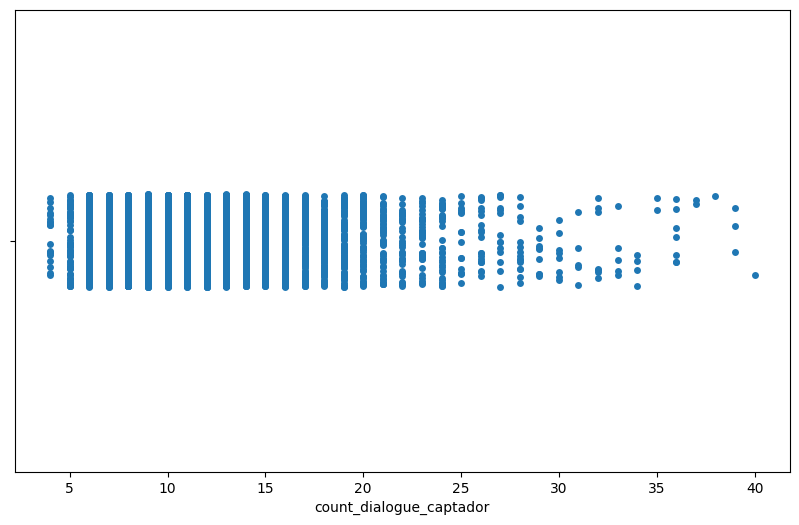

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

La importancia de esto es que el modelo no se vea afectado por datos que se encuentren demasiado alejados de la distribución normal de los datos, es decir, que describa el comportamiento común de estos.

#### Variable: count_dialogue_captador

In [ ]:
var_check = 'count_dialogue_cliente'

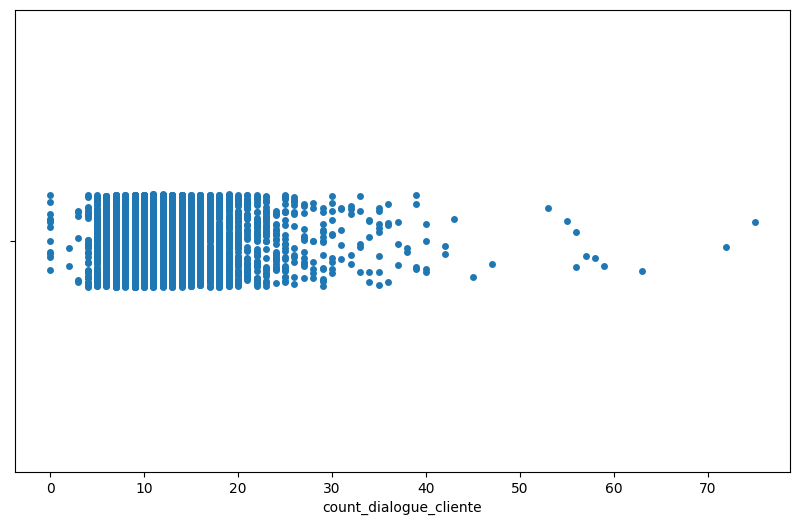

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

In [ ]:
df.loc[df[var_check] > 40, [var_check]] = np.nan
df.loc[df[var_check] < 4, [var_check]] = np.nan
nan_percentage = df[var_check].isna().sum() / len(df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en count_dialogue_cliente: 0.53%


In [ ]:
df[var_check] = df[var_check].fillna(df[var_check].median())

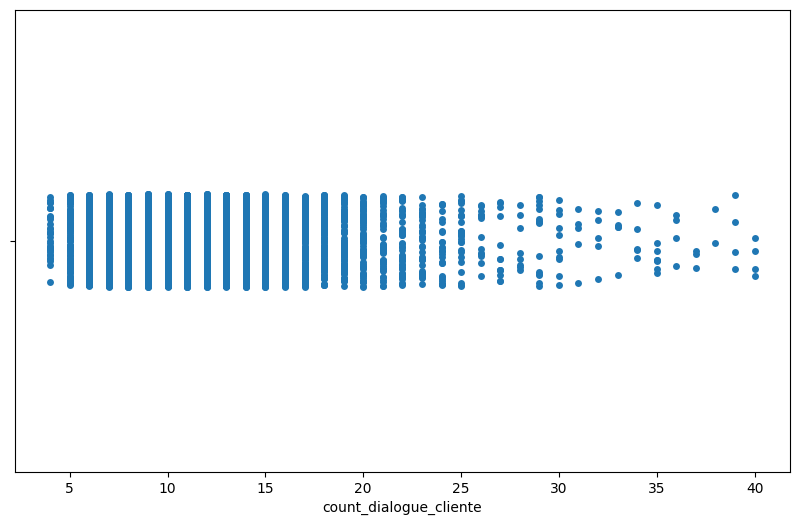

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

Se preguntarán por qué reemplazamos el valor por uno «falso» en lugar de eliminar la fila, pues en ese caso perderíamos todos los demás valores obtenidos a partir de esa conversación. En el peor de los casos, estaríamos reemplazando datos que no aportarían información al modelo, ya que se comportan como la mayoría de los datos.

#### Variable: num_word_text_captador

In [ ]:
var_check = 'num_word_text_captador'

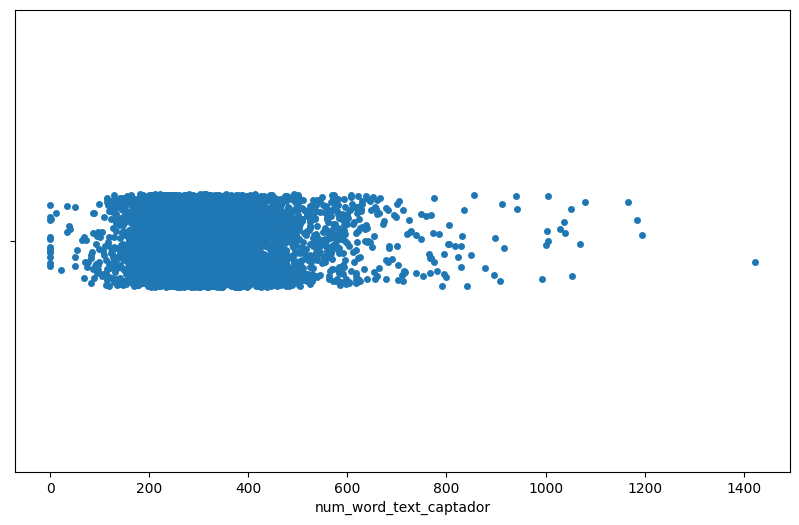

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

In [ ]:
df.loc[df[var_check] > 900, [var_check]] = np.nan
df.loc[df[var_check] < 50, [var_check]] = np.nan
nan_percentage = df[var_check].isna().sum() / len(df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en num_word_text_captador: 0.61%


In [ ]:
df[var_check] = df[var_check].fillna(df[var_check].median())

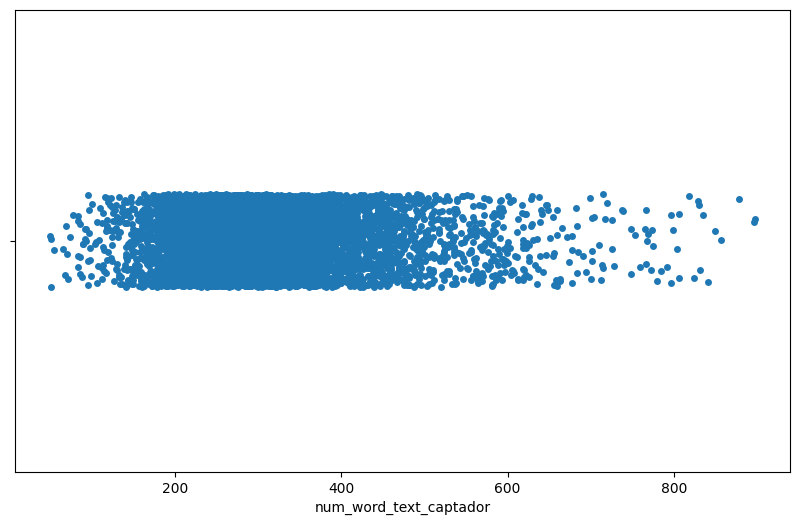

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

Este caso es interesante, ya que existen casos con muy pocos elementos. Esos casos son ciertamente atípicos, pues una conversación en la que una de las partes no participa no es un dato importante en relación con una conversación normal.

#### Variable: num_word_text_cliente

In [ ]:
var_check = 'num_word_text_cliente'

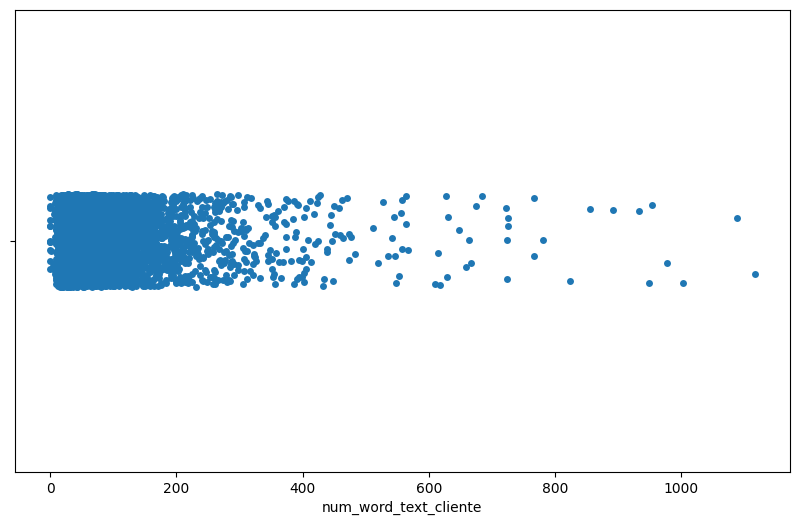

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

In [ ]:
df.loc[df[var_check] > 500, [var_check]] = np.nan
df.loc[df[var_check] < 10, [var_check]] = np.nan
nan_percentage = df[var_check].isna().sum() / len(df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en num_word_text_cliente: 1.26%


In [ ]:
df[var_check] = df[var_check].fillna(df[var_check].median())

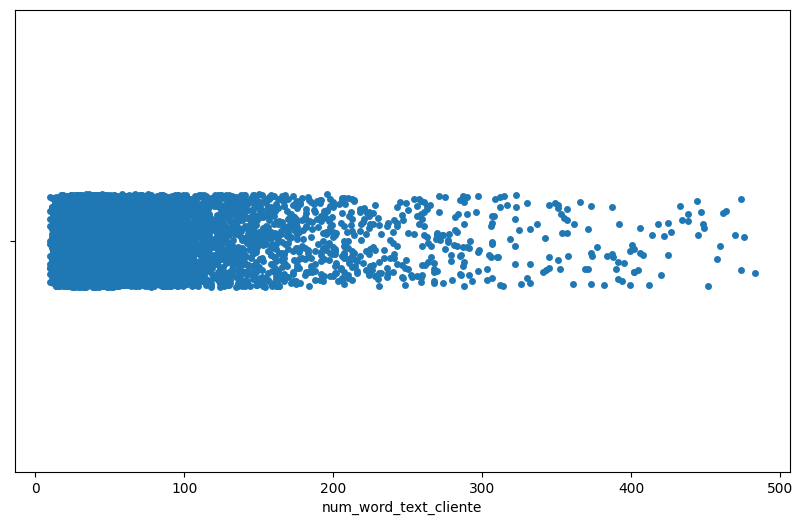

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()

En general, nos importa encontrar los patrones generales del modelo para poder obtener una herramienta o generar valor mediante XAI.

### Transformar variables

Aquí se pueden hacer múltiples transformaciones, fusionar variables o arreglar variables categóricas.  

A continuación, transformaré las variables de análisis de sentimiento para centrarnos principalmente en las conversaciones positivas. Esta decisión se basa en medir el impacto de la buena actitud de ambas partes en relación con la variable objetivo.

**Se trata de una decisión arbitraria que también facilitará bastante el proceso, pero que puede variar en cada caso.*

#### Variable: sentiment_text

In [ ]:
var_check = 'sentiment_text'

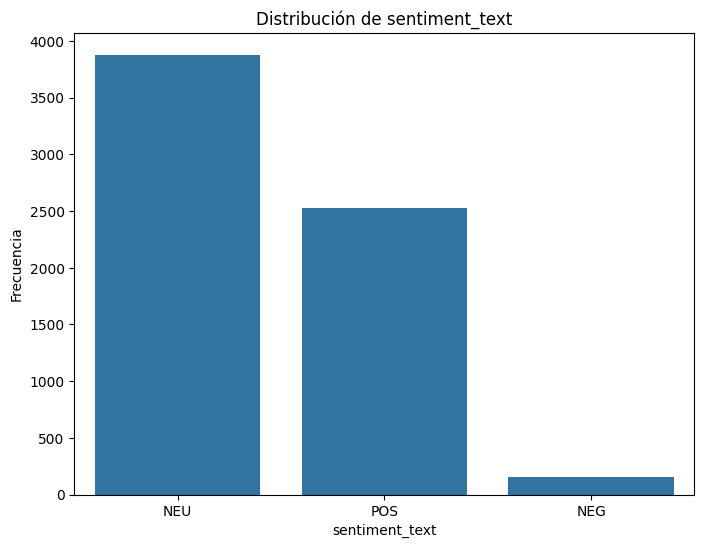

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df[var_check] = df[var_check].replace('NEG', 'NEU')
df[var_check] = df[var_check].replace('NEU', 'NOPOS')

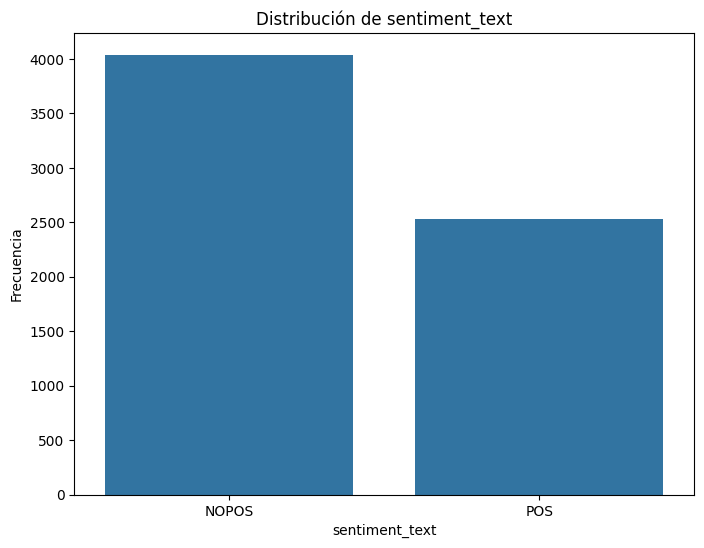

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()

#### Variable: sentiment_captador

In [ ]:
var_check = 'sentiment_captador'

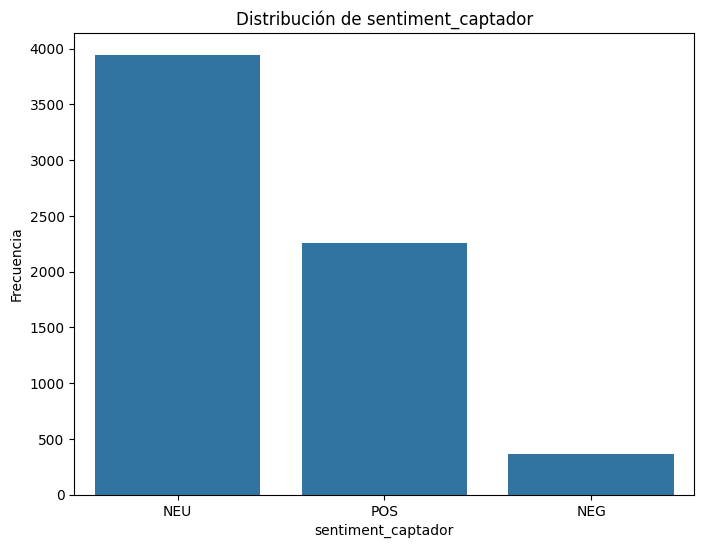

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df[var_check] = df[var_check].replace('NEG', 'NEU')
df[var_check] = df[var_check].replace('NEU', 'NOPOS')

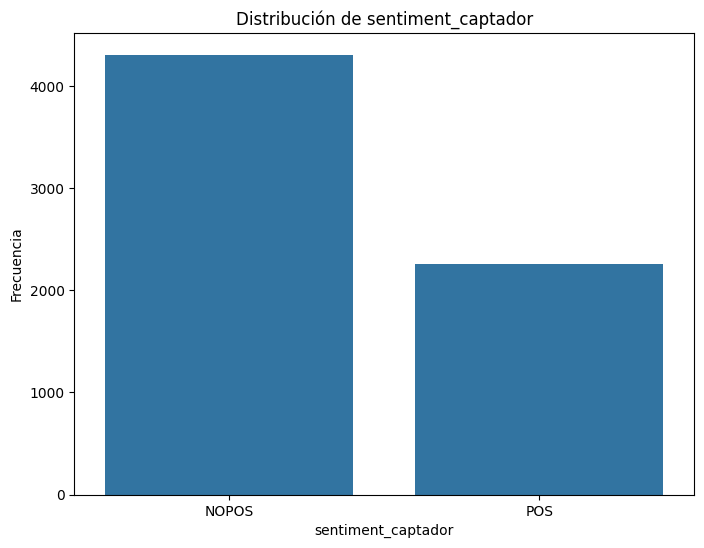

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()

#### Variable: sentiment_cliente

In [ ]:
var_check = 'sentiment_cliente'

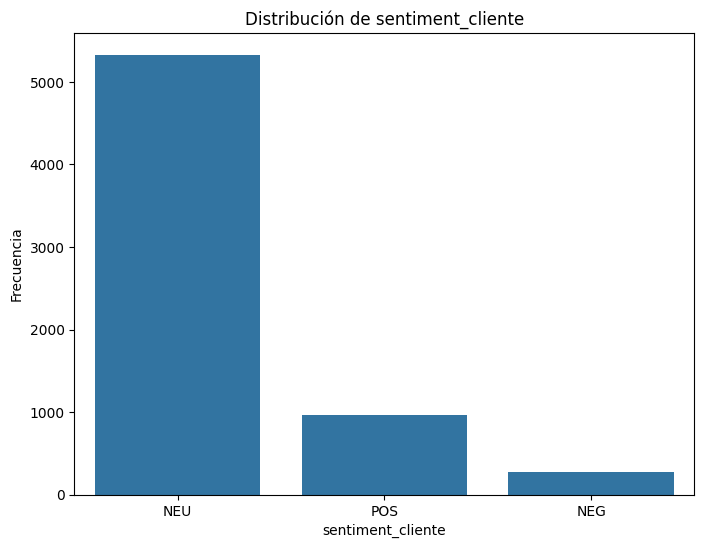

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df[var_check] = df[var_check].replace('NEG', 'NEU')
df[var_check] = df[var_check].replace('NEU', 'NOPOS')

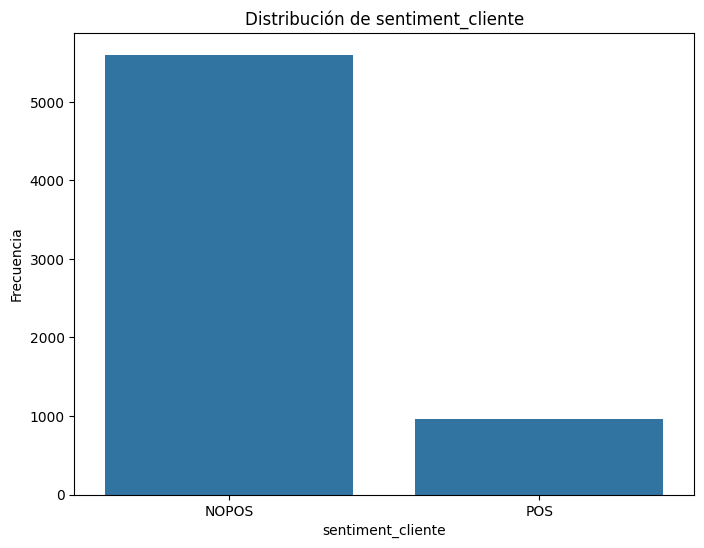

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()

En general, se forzó para tener dos variables, pero no siempre es posible hacer eso. En cualquier caso, traten de trabajar siempre con booleanos, siempre y cuando su enfoque se lo permita.

### Generar variables adicionales

Si pueden generar más valor a partir de los datos de los que disponen, aprovechen para crear nuevas variables que tengan sentido.

In [ ]:
df['word_per_dialogue_cliente'] = df['num_word_text_cliente'] / df['count_dialogue_cliente']
df['word_per_dialogue_operador'] = df['num_word_text_captador'] / df['count_dialogue_captador']

df['proportion_dialogue_cliente'] = df['count_dialogue_cliente'] / (df['count_dialogue_cliente'] + df['count_dialogue_captador'])
df['proportion_dialogue_captador'] = df['count_dialogue_captador'] / (df['count_dialogue_cliente'] + df['count_dialogue_captador'])

### Transformación matemática

Esta es la razón por la que en las variables categóricas nos quedamos con dos categorías, pues esto se puede transformar en un booleano, como puede ver a continuación.

**Revise las columnas de sentimiento.*

In [ ]:
df = pd.get_dummies(df, columns=["sentiment_text", "sentiment_cliente", "sentiment_captador"],drop_first=True)
df['result'] = df['result'].astype(bool)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6568 entries, 0 to 6567
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   result                        6568 non-null   bool   
 1   num_word_text                 6568 non-null   float64
 2   count_dialogue_captador       6568 non-null   float64
 3   count_dialogue_cliente        6568 non-null   float64
 4   num_word_text_captador        6568 non-null   float64
 5   num_word_text_cliente         6568 non-null   float64
 6   word_per_dialogue_cliente     6568 non-null   float64
 7   word_per_dialogue_operador    6568 non-null   float64
 8   proportion_dialogue_cliente   6568 non-null   float64
 9   proportion_dialogue_captador  6568 non-null   float64
 10  sentiment_text_POS            6568 non-null   bool   
 11  sentiment_cliente_POS         6568 non-null   bool   
 12  sentiment_captador_POS        6568 non-null   bool   
dtypes: bool(

### Normalizar datos

Este paso puede resultar un poco extraño, pero básicamente transformamos todos los datos a una escala entre 0 y 1, lo que facilita su uso en ciertos entrenamientos y genera un intervalo comparable. Esto es muy útil si queremos comparar el impacto de las variables después.

In [ ]:
variables_to_scale = ['num_word_text', 'count_dialogue_captador', 'count_dialogue_cliente',
                      'num_word_text_captador', 'num_word_text_cliente', 'word_per_dialogue_cliente',
                      'word_per_dialogue_operador', 'proportion_dialogue_cliente',
                      'proportion_dialogue_captador']

for var in variables_to_scale:
    scaler = MinMaxScaler()
    df[var] = scaler.fit_transform(df[[var]])

df

,result,num_word_text,count_dialogue_captador,count_dialogue_cliente,num_word_text_captador,num_word_text_cliente,word_per_dialogue_cliente,word_per_dialogue_operador,proportion_dialogue_cliente,proportion_dialogue_captador,sentiment_text_POS,sentiment_cliente_POS,sentiment_captador_POS
0,True,0.167656,0.111111,0.083333,0.238489,0.154334,0.253625,0.383746,0.437109,0.562891,False,False,False
1,True,0.178042,0.194444,0.222222,0.291617,0.076110,0.062995,0.321300,0.534701,0.465299,True,False,False
2,True,0.215875,0.222222,0.166667,0.342385,0.099366,0.107343,0.339803,0.415630,0.584370,False,False,True
3,True,0.178042,0.166667,0.166667,0.302243,0.059197,0.062203,0.371257,0.496178,0.503822,False,False,False
4,False,0.229228,0.138889,0.166667,0.377804,0.073996,0.078834,0.517117,0.542811,0.457189,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6563,True,0.646884,0.638889,0.638889,0.785124,0.427061,0.158467,0.314105,0.496178,0.503822,False,False,False
6564,True,0.189169,0.138889,0.138889,0.353011,0.004228,0.003600,0.484738,0.496178,0.503822,True,True,True
6565,True,0.096439,0.138889,0.138889,0.174734,0.061311,0.074874,0.251917,0.496178,0.503822,False,False,False
6566,False,0.079377,0.055556,0.055556,0.138135,0.093023,0.185745,0.332864,0.496178,0.503822,True,False,False


### Selección de variables.

Cuantas más variables haya, más le complicará el modelo, y si le agregamos variables que pueden ser «ruido», perjudicaremos el rendimiento del modelo. Por eso es útil revisar qué podemos descartar, pero sin descartar por descartar, sino buscando aquellos que no nos sirven.

#### Redudancia

En este caso, buscamos aquellas variables que son redundantes, es decir, que ofrecen la misma información. Lo importante es eliminar la que posiblemente ofrezca un poco menos de información.

Si alguien quiere saber cómo se hace esto, se aleja del marco de este ramo y hay mucha matemática y teorías.

<Axes: >

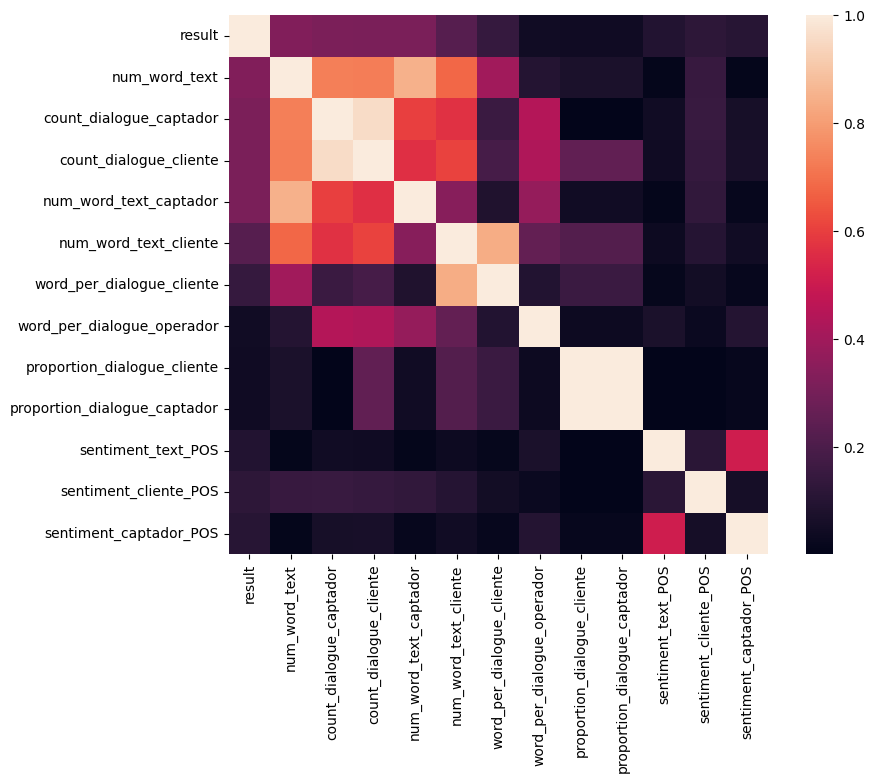

In [ ]:
corrmat = df.corr().abs()
f, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corrmat, square=True)

##### Redundancia: count_dialogue_captador

In [ ]:
corrmat.loc["count_dialogue_captador"]

,count_dialogue_captador
result,0.315778
num_word_text,0.734164
count_dialogue_captador,1.000000
count_dialogue_cliente,0.958619
num_word_text_captador,0.598611
num_word_text_cliente,0.568172
word_per_dialogue_cliente,0.154444
word_per_dialogue_operador,0.445473
proportion_dialogue_cliente,0.005058
proportion_dialogue_captador,0.005058


In [ ]:
cut_points = df['count_dialogue_captador'].quantile([0, .2, .4, .6, .8, 1]) #el array es como quiero dividir los datos
Ingreso_binned = pd.cut(df['count_dialogue_captador'], bins =cut_points, include_lowest= True ) # bins puede ser un int tambien con el numero de diviciones

tbl = pd.crosstab(index= Ingreso_binned,columns=df['result'])
stat, p, dof, expected = chi2_contingency(tbl)
print('Valor chi cuadrado = %d' % stat)
print('P-valor =%f' % p)

cut_points = df['count_dialogue_cliente'].quantile([0, .2, .4, .6, .8, 1])
Ingreso2_binned = pd.cut(df['count_dialogue_cliente'], bins =cut_points, include_lowest= True )

tbl = pd.crosstab(index=Ingreso2_binned, columns=df['result'])
stat, p, dof, expected = chi2_contingency(tbl)
print('Valor chi cuadrado = %d' % stat)
print('P-valor =%f' % p)

Valor chi cuadrado = 1033
P-valor =0.000000
Valor chi cuadrado = 1105
P-valor =0.000000


In [ ]:
del df['count_dialogue_captador']

##### Redundancia: proportion_dialogue_captador

In [ ]:
corrmat.loc["proportion_dialogue_captador"]

,proportion_dialogue_captador
result,0.042362
num_word_text,0.072879
count_dialogue_captador,0.005058
count_dialogue_cliente,0.253927
num_word_text_captador,0.047664
num_word_text_cliente,0.216771
word_per_dialogue_cliente,0.155379
word_per_dialogue_operador,0.035090
proportion_dialogue_cliente,1.000000
proportion_dialogue_captador,1.000000


In [ ]:
cut_points = df['proportion_dialogue_captador'].quantile([0, .2, .4, .6, .8, 1]) #el array es como quiero dividir los datos
# Drop duplicates and sort the cut_points
cut_points = cut_points.drop_duplicates().sort_values()
Ingreso_binned = pd.cut(df['proportion_dialogue_captador'], bins=cut_points, include_lowest=True, duplicates='drop') # bins puede ser un int tambien con el numero de diviciones

tbl = pd.crosstab(index=Ingreso_binned, columns=df['result'])
stat, p, dof, expected = chi2_contingency(tbl)
print('Valor chi cuadrado = %d' % stat)
print('P-valor =%f' % p)

cut_points = df['proportion_dialogue_cliente'].quantile([0, .2, .4, .6, .8, 1])
# Drop duplicates and sort the cut_points
cut_points = cut_points.drop_duplicates().sort_values()
Ingreso2_binned = pd.cut(df['proportion_dialogue_cliente'], bins=cut_points, include_lowest=True, duplicates='drop')

tbl = pd.crosstab(index=Ingreso2_binned, columns=df['result'])
stat, p, dof, expected = chi2_contingency(tbl)
print('Valor chi cuadrado = %d' % stat)
print('P-valor =%f' % p)

Valor chi cuadrado = 182
P-valor =0.000000
Valor chi cuadrado = 89
P-valor =0.000000


In [ ]:
del df['proportion_dialogue_cliente']

##### Redundancia: word_per_dialogue_cliente

In [ ]:
corrmat.loc["word_per_dialogue_cliente"]

,word_per_dialogue_cliente
result,0.145433
num_word_text,0.401887
count_dialogue_captador,0.154444
count_dialogue_cliente,0.185997
num_word_text_captador,0.084632
num_word_text_cliente,0.838451
word_per_dialogue_cliente,1.000000
word_per_dialogue_operador,0.093640
proportion_dialogue_cliente,0.155379
proportion_dialogue_captador,0.155379


In [ ]:
cut_points = df['word_per_dialogue_cliente'].quantile([0, .2, .4, .6, .8, 1]) #el array es como quiero dividir los datos
# Drop duplicates and sort the cut_points
cut_points = cut_points.drop_duplicates().sort_values()
Ingreso_binned = pd.cut(df['word_per_dialogue_cliente'], bins=cut_points, include_lowest=True, duplicates='drop') # bins puede ser un int tambien con el numero de diviciones

tbl = pd.crosstab(index=Ingreso_binned, columns=df['result'])
stat, p, dof, expected = chi2_contingency(tbl)
print('Valor chi cuadrado = %d' % stat)
print('P-valor =%f' % p)

cut_points = df['num_word_text_cliente'].quantile([0, .2, .4, .6, .8, 1])
# Drop duplicates and sort the cut_points
cut_points = cut_points.drop_duplicates().sort_values()
Ingreso2_binned = pd.cut(df['num_word_text_cliente'], bins=cut_points, include_lowest=True, duplicates='drop')

tbl = pd.crosstab(index=Ingreso2_binned, columns=df['result'])
stat, p, dof, expected = chi2_contingency(tbl)
print('Valor chi cuadrado = %d' % stat)
print('P-valor =%f' % p)

Valor chi cuadrado = 290
P-valor =0.000000
Valor chi cuadrado = 816
P-valor =0.000000


In [ ]:
del df['word_per_dialogue_cliente']

##### Chequeo

<Axes: >

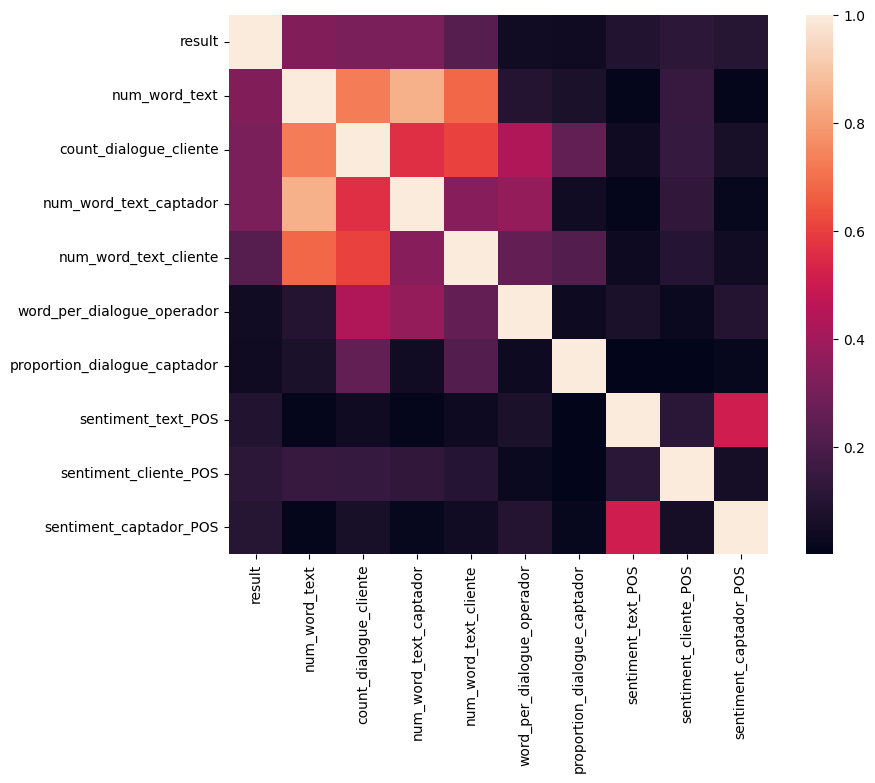

In [ ]:
corrmat = df.corr().abs()
f, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corrmat, square=True)

#### Importancia de las variables

En este caso, usando más matemáticas, es posible determinar qué variables no son útiles. Básicamente, se utiliza un test estadístico para determinar si una variable es representativa en función de la variable objetivo y, en caso de no serlo, podemos descartarla.

Como decía, se sale del marco, pero lo importante es aplicarlo y obtener un conjunto de datos efectivo para el posterior entrenamiento.

In [ ]:
X = df.loc[:, df.columns != 'result']
y = df.loc[:, df.columns == 'result']
X.shape

(6568, 9)

In [ ]:
X_new = SelectKBest(k=5).fit(X, y.values.ravel())


results_df = pd.DataFrame({
    'Variable': X.columns,
    'F_score': X_new.scores_,
    'p_value': X_new.pvalues_,
    'Rechaza H0': X_new.pvalues_ < 0.05
})

results_df

,Variable,F_score,p_value,Rechaza H0
0,num_word_text,791.601411,1.515284e-164,True
1,count_dialogue_cliente,701.517529,5.869312e-147,True
2,num_word_text_captador,699.269264,1.623164e-146,True
3,num_word_text_cliente,356.424746,1.850035e-77,True
4,word_per_dialogue_operador,13.375021,2.569935e-04,True
5,proportion_dialogue_captador,11.804048,5.946814e-04,True
6,sentiment_text_POS,58.878348,1.920933e-14,True
7,sentiment_cliente_POS,95.987228,1.648464e-22,True
8,sentiment_captador_POS,72.904907,1.672338e-17,True


## Ajuste de variables booleanas

Por alguna razón, si no ajustamos las variables de booleano a binario, podría haber problemas, pero básicamente True es 1 y False es 0.

In [ ]:
for col_bool in ["result", "sentiment_captador_POS", "sentiment_cliente_POS", "sentiment_text_POS"]:
  df[col_bool] = df[col_bool].astype(int)

df

,result,num_word_text,count_dialogue_cliente,num_word_text_captador,num_word_text_cliente,word_per_dialogue_operador,proportion_dialogue_captador,sentiment_text_POS,sentiment_cliente_POS,sentiment_captador_POS
0,1,0.167656,0.083333,0.238489,0.154334,0.383746,0.562891,0,0,0
1,1,0.178042,0.222222,0.291617,0.076110,0.321300,0.465299,1,0,0
2,1,0.215875,0.166667,0.342385,0.099366,0.339803,0.584370,0,0,1
3,1,0.178042,0.166667,0.302243,0.059197,0.371257,0.503822,0,0,0
4,0,0.229228,0.166667,0.377804,0.073996,0.517117,0.457189,1,0,1
...,...,...,...,...,...,...,...,...,...,...
6563,1,0.646884,0.638889,0.785124,0.427061,0.314105,0.503822,0,0,0
6564,1,0.189169,0.138889,0.353011,0.004228,0.484738,0.503822,1,1,1
6565,1,0.096439,0.138889,0.174734,0.061311,0.251917,0.503822,0,0,0
6566,0,0.079377,0.055556,0.138135,0.093023,0.332864,0.503822,1,0,0


## Guardar Resultado

El resultado final corresponde al siguiente conjunto de datos

In [ ]:
df

,result,num_word_text,count_dialogue_cliente,num_word_text_captador,num_word_text_cliente,word_per_dialogue_operador,proportion_dialogue_captador,sentiment_text_POS,sentiment_cliente_POS,sentiment_captador_POS
0,1,0.167656,0.083333,0.238489,0.154334,0.383746,0.562891,0,0,0
1,1,0.178042,0.222222,0.291617,0.076110,0.321300,0.465299,1,0,0
2,1,0.215875,0.166667,0.342385,0.099366,0.339803,0.584370,0,0,1
3,1,0.178042,0.166667,0.302243,0.059197,0.371257,0.503822,0,0,0
4,0,0.229228,0.166667,0.377804,0.073996,0.517117,0.457189,1,0,1
...,...,...,...,...,...,...,...,...,...,...
6563,1,0.646884,0.638889,0.785124,0.427061,0.314105,0.503822,0,0,0
6564,1,0.189169,0.138889,0.353011,0.004228,0.484738,0.503822,1,1,1
6565,1,0.096439,0.138889,0.174734,0.061311,0.251917,0.503822,0,0,0
6566,0,0.079377,0.055556,0.138135,0.093023,0.332864,0.503822,1,0,0


In [ ]:
df.to_csv("/content/drive/MyDrive/IA_Aplicada/2026/IAA_Ayundatias_2026/IAA_ayun02_2026/pp_datos_tabulares_calls.csv", sep=";")

# Entrenamiento y evaluación

Para el entrenamiento vamos a estar trabajando con diferentes modelos, los cuales serán:

* **Random Forest**: Construye múltiples árboles de decisión de manera aleatoria y los combina para tomar decisiones más robustas (por mayoría en clasificación o promedio en regresión).
* **Redes Neuronales**: Los datos pasan por capas ocultas donde se aplican funciones de activación para aprender representaciones complejas.

Sin embargo, existen también regresiones logísticas, KNN, árboles de decisión, Gradient Boosting Machines y Naive Bayes. Además, muchos de estos modelos tienen diferentes enfoques o configuraciones.

Para este laboratorio, nos enfocaremos en analizar unos pocos para que vean cómo implementarlos de forma practica usando `sklearn`.

**Es importante señalar que la métrica relevante en este caso es el AUC, como vimos en el primer laboratorio. Cuando trabajemos con modelos binarios, esta métrica será la más relevante.**

**Debo aclarar que SVM presentó algunos problemas, pero será interesante aclarar algunas cosas sobre la métrica AUC.*

## Librerías

Para ello, utilizaremos diferentes bibliotecas que ya hemos visto. Ahora, `Sklearn` desempeñará un papel más importante. No veremos `transformers` (porque no los usaremos) y, como pequeña adición, usaremos `rich` para la visualización en consola.

In [ ]:
!pip install -q ipywidgets==7.7.1 rich

In [ ]:
import os
import time
import random
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Rich para visualización en consola
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

# Numpy y pandas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Modelado y preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Evaluación
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, classification_report

from joblib import dump, load

## Cargar los datos

El siguiente paso es montar Google Drive para poder acceder a nuestro almacenamiento

**Cuando corra la siguiente línea, siga las intrucciones indicando la cuenta de Google correspondiente y aceptando las condiciones.**

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


En este caso, ya tenemos los datos que obtuvimos en el laboratorio anterior, por lo que solo los vamos a cargar.

In [ ]:
import pandas as pd

data_set = pd.read_csv("/content/drive/MyDrive/IA_Aplicada/2026/IAA_Ayundatias_2026/IAA_ayun02_2026/pp_datos_tabulares_calls.csv", sep=";", index_col=[0])

data_set

,result,num_word_text,count_dialogue_cliente,num_word_text_captador,num_word_text_cliente,word_per_dialogue_operador,proportion_dialogue_captador,sentiment_text_POS,sentiment_cliente_POS,sentiment_captador_POS
0,1,0.167656,0.083333,0.238489,0.154334,0.383746,0.562891,0,0,0
1,1,0.178042,0.222222,0.291617,0.076110,0.321300,0.465299,1,0,0
2,1,0.215875,0.166667,0.342385,0.099366,0.339803,0.584370,0,0,1
3,1,0.178042,0.166667,0.302243,0.059197,0.371257,0.503822,0,0,0
4,0,0.229228,0.166667,0.377804,0.073996,0.517117,0.457189,1,0,1
...,...,...,...,...,...,...,...,...,...,...
6563,1,0.646884,0.638889,0.785124,0.427061,0.314105,0.503822,0,0,0
6564,1,0.189169,0.138889,0.353011,0.004228,0.484738,0.503822,1,1,1
6565,1,0.096439,0.138889,0.174734,0.061311,0.251917,0.503822,0,0,0
6566,0,0.079377,0.055556,0.138135,0.093023,0.332864,0.503822,1,0,0


## Constantes

A continuación, definimos algunos elementos constantes (para que no esté todo desordenado) y lo más importante: definimos los modelos. Es importante que utilicen la estructura para que sea posible usar las funciones de entrenamiento y evaluación.

In [ ]:
seed_val = 42

console = Console()

models = {
    "random_forest": {
        "model_class": RandomForestClassifier(n_estimators=100),  # Clasificador de bosque aleatorio con 100 árboles
        "name_pipeline": "rf",
        "params": dict(
            rf__max_features=[2, 4, 6],  # Número máximo de características consideradas al dividir un nodo; controla el sobreajuste
            rf__max_depth=[4, 6],  # Profundidad máxima de los árboles; previene sobreajuste si se limita
            rf__criterion=['gini', 'entropy']  # Criterio para medir la calidad de una división; Gini es más rápido, Entropía es más informativo
        )
    },
    "red_neuronal": {
        "model_class": MLPClassifier(max_iter=1000, solver='lbfgs'),  # Perceptrón multicapa con solucionador 'lbfgs', eficiente para pequeños conjuntos de datos
        "name_pipeline": "red",
        "params": dict(
            red__max_iter=[50, 100],  # Número máximo de iteraciones de entrenamiento; puede afectar la convergencia del modelo
            red__alpha=[0.1, 0.01, 0.001],  # Tasa de regularización L2; evita el sobreajuste penalizando pesos grandes
            red__hidden_layer_sizes=[2, 3, 5]  # Número de neuronas en la(s) capa(s) oculta(s); controla la capacidad de representación del modelo
        )
    }
}


results = {}

básicamente, lo que buscamos es una mayor reproductibilidad del laboratorio.

In [ ]:
np.random.seed(seed_val)
random.seed(seed_val)

## Definir conjuntos

### Conjuntos de entrenamiento y evaluación

In [ ]:
y = data_set["result"]
del data_set["result"]
X = data_set

Vamos a definir los conjuntos de prueba y entrenamiento en una proporción del 30 % y 70 %, respectivamente.

«X» representa los datos y «Y» el resultado o la variable objetivo.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed_val)

Revisaremos si los datos están desequilibrados.

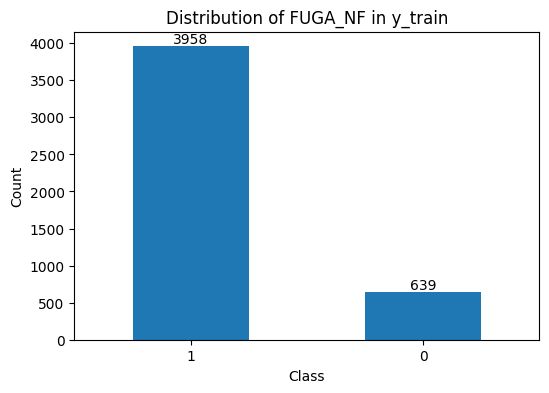

In [ ]:
plt.figure(figsize=(6, 4))
ax = y_train.value_counts().plot(kind='bar')
plt.title('Distribution of y_train')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

Efectivamente, están desequilibrados, pero esto es algo que vamos a solucionar durante el entrenamiento.

## Funciones de utilidad

### Función de entrenamiento

Esta función entrena un modelo de machine learning utilizando un pipeline que incluye SMOTE para balanceo de clases y una búsqueda de hiperparámetros con GridSearchCV. Mide el tiempo de entrenamiento, muestra los mejores parámetros encontrados y retorna el mejor modelo ajustado junto con el tiempo que tomó entrenarlo.

In [ ]:
def train(model_name, model_class, name_pipeline, params, x_train_values, y_train_values):
    console.rule(f"[bold green]Entrenando modelo: {model_name}[/bold green]")

    # Define un pipeline de entrenamiento:
    # - Aplica sobremuestreo con SMOTE para balancear las clases
    # - Aplica el modelo especificado
    model_pipeline = Pipeline(steps=[
        ('sampling', SMOTE()),
        (name_pipeline, model_class)
    ])

    # Crea un objeto GridSearchCV para buscar los mejores hiperparámetros
    # Usa validación cruzada de 10 folds y paraleliza con todos los núcleos disponibles
    red_cv = GridSearchCV(model_pipeline, params, n_jobs=-1, cv=10)

    # Registra el tiempo de inicio del entrenamiento
    start_time = time.time()

    # Ajusta el modelo al conjunto de entrenamiento
    red_cv.fit(x_train_values, y_train_values)

    # Registra el tiempo al finalizar el entrenamiento
    end_time = time.time()

    # Calcula el tiempo total de entrenamiento
    train_time = end_time - start_time

    # Obtiene el mejor modelo ajustado y los mejores hiperparámetros encontrados
    best = red_cv.best_estimator_
    best_params = red_cv.best_params_

    console.rule(f"[bold blue]Mejores parámetros para '{model_name}'[/bold blue]")

    table = Table(title=f"Parámetros Óptimos - {model_name}", show_header=True, header_style="bold magenta")
    table.add_column("Parámetro")
    table.add_column("Valor")

    for k, v in best_params.items():
        table.add_row(k.replace("red__", ""), str(v))

    console.print(table)

    # Retorna el mejor modelo entrenado y el tiempo de entrenamiento
    return best, train_time


### Función de evaluación

Esta función evalúa el rendimiento del modelo entrenado sobre un conjunto de prueba. Calcula métricas como precisión y AUC, genera y muestra la matriz de confusión, y presenta los resultados en un panel visual en consola. Retorna las métricas clave para análisis posterior.

In [ ]:
def evaluate(model_name, best_model, x_test_values, y_test_values):
    # Calcula la precisión del modelo en el conjunto de prueba
    accuracy = best_model.score(x_test_values, y_test_values)

    # Genera las predicciones del modelo
    y_pred = best_model.predict(x_test_values)

    # Calcula la matriz de confusión y la muestra gráficamente
    cm = confusion_matrix(y_test_values, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    print()  # Línea vacía para separar la visualización

    # Calcula el AUC (Área Bajo la Curva ROC)
    # Se usa la probabilidad predicha de la clase positiva
    auc = roc_auc_score(y_test_values, best_model.predict_proba(x_test_values)[:, 1])

    panel_text = (
        f"[bold yellow]Evaluación del modelo:[/bold yellow] [cyan]{model_name}[/cyan]\n\n"
        f"[bold green]Precisión:[/bold green] {accuracy:.2f}\n"
        f"[bold green]AUC:[/bold green] {auc:.3f}"
    )

    console.print(Panel.fit(panel_text, title="Resultados", border_style="blue"))

    # Obtener el reporte como diccionario
    report_dict = classification_report(y_test_values, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose().round(3)

    # Crear tabla Rich
    table = Table(title=f"Classification Report {model_name}", show_lines=True)

    # Añadir columnas
    table.add_column("Class", justify="left")
    table.add_column("Precision", justify="right")
    table.add_column("Recall", justify="right")
    table.add_column("F1-Score", justify="right")
    table.add_column("Support", justify="right")

    # Añadir filas desde el DataFrame
    for index, row in report_df.iterrows():
        precision = str(row.get("precision", ""))
        recall = str(row.get("recall", ""))
        f1 = str(row.get("f1-score", ""))
        support = str(int(row["support"])) if not pd.isna(row.get("support")) else ""
        table.add_row(index, precision, recall, f1, support)

    # Imprimir la tabla
    console.print(table)

    # Retorna las métricas calculadas
    return accuracy, auc


## Flujo Principal

Esto es similar a lo hecho antes en Laboratorio 1, donde se prueba todo y se muestra todo el proceso de cada modelo.

────────────────────────────────────── Entrenando y evaluando: random_forest ──────────────────────────────────────

──────────────────────────────────────── Entrenando modelo: random_forest ─────────────────────────────────────────

───────────────────────────────────── Mejores parámetros para 'random_forest' ─────────────────────────────────────

    Parámetros Óptimos -    
       random_forest        
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Parámetro        ┃ Valor ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ rf__criterion    │ gini  │
│ rf__max_depth    │ 6     │
│ rf__max_features │ 4     │
└──────────────────┴───────┘

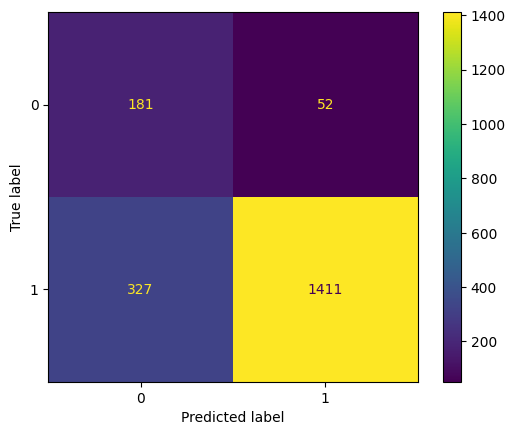

╭───────────── Resultados ─────────────╮
│ Evaluación del modelo: random_forest │
│                                      │
│ Precisión: 0.81                      │
│ AUC: 0.887                           │
╰──────────────────────────────────────╯

           Classification Report random_forest            
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Class        ┃ Precision ┃ Recall ┃ F1-Score ┃ Support ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ 0            │     0.356 │  0.777 │    0.489 │     233 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ 1            │     0.964 │  0.812 │    0.882 │    1738 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ accuracy     │     0.808 │  0.808 │    0.808 │       0 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ macro avg    │      0.66 │  0.794 │    0.685 │    1971 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ weighted avg │     0.893 │  0.808 │    0.835 │    1971 │
└──────────────┴───────────┴────────┴──────────┴─────────┘

────────────────────────────────────── Entrenando y evaluando: red_neuronal ───────────────────────────────────────

───────────────────────────────────────── Entrenando modelo: red_neuronal ─────────────────────────────────────────

───────────────────────────────────── Mejores parámetros para 'red_neuronal' ──────────────────────────────────────

     Parámetros Óptimos -     
         red_neuronal         
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Parámetro          ┃ Valor ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ alpha              │ 0.001 │
│ hidden_layer_sizes │ 2     │
│ max_iter           │ 100   │
└────────────────────┴───────┘

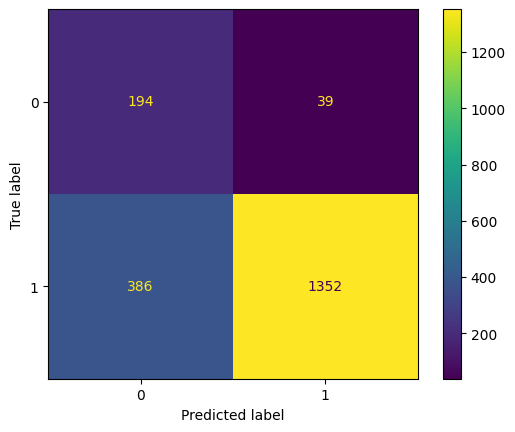

╭──────────── Resultados ─────────────╮
│ Evaluación del modelo: red_neuronal │
│                                     │
│ Precisión: 0.78                     │
│ AUC: 0.888                          │
╰─────────────────────────────────────╯

            Classification Report red_neuronal            
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Class        ┃ Precision ┃ Recall ┃ F1-Score ┃ Support ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ 0            │     0.334 │  0.833 │    0.477 │     233 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ 1            │     0.972 │  0.778 │    0.864 │    1738 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ accuracy     │     0.784 │  0.784 │    0.784 │       0 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ macro avg    │     0.653 │  0.805 │    0.671 │    1971 │
├──────────────┼───────────┼────────┼──────────┼─────────┤
│ weighted avg │     0.897 │  0.784 │    0.818 │    1971 │
└──────────────┴───────────┴────────┴──────────┴─────────┘

In [ ]:
for model_name, model_info in models.items():
    console.rule(f"[bold cyan]Entrenando y evaluando: {model_name}[/bold cyan]")
    print()

    model_class = model_info["model_class"]
    name_pipeline = model_info["name_pipeline"]
    params = model_info["params"]

    best_model, train_time = train(model_name, model_class, name_pipeline, params, X_train, y_train)
    print()
    accuracy, auc = evaluate(model_name, best_model, X_test, y_test)

    results[model_name] = {
        "best": best_model,
        "train_time": train_time,
        "accuracy": accuracy,
        "auc": auc
    }
    print()

## Resultados

In [ ]:
# Tabla resumen de resultados
console.rule("[bold green]Resumen de resultados[/bold green]")

summary_table = Table(title="Rendimiento por Modelo", header_style="bold magenta")
summary_table.add_column("Modelo", style="cyan", no_wrap=True)
summary_table.add_column("Precisión", justify="right")
summary_table.add_column("AUC", justify="right")
summary_table.add_column("Time (s)", justify="right")

for name, metrics in results.items():
    summary_table.add_row(
        name,
        f"{metrics['accuracy']:.2f}",
        f"{metrics['auc']:.2f}",
        f"{metrics['train_time']:.0f}"
    )

console.print(summary_table)

────────────────────────────────────────────── Resumen de resultados ──────────────────────────────────────────────

            Rendimiento por Modelo             
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┓
┃ Modelo        ┃ Precisión ┃  AUC ┃ Time (s) ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━┩
│ random_forest │      0.81 │ 0.89 │      133 │
│ red_neuronal  │      0.78 │ 0.89 │       21 │
└───────────────┴───────────┴──────┴──────────┘

Como podemos observar, Random Forest y la Red Neuronal presentan un AUC muy similar (0.89), lo que indica un desempeño comparable en la capacidad de discriminación entre clases. Sin embargo, la Red Neuronal tiene un tiempo de entrenamiento significativamente menor (24 segundos frente a 128), aunque con una precisión ligeramente inferior (0.78 vs 0.81). En contraste, Random Forest muestra una mejor precisión, pero requiere más tiempo de entrenamiento.

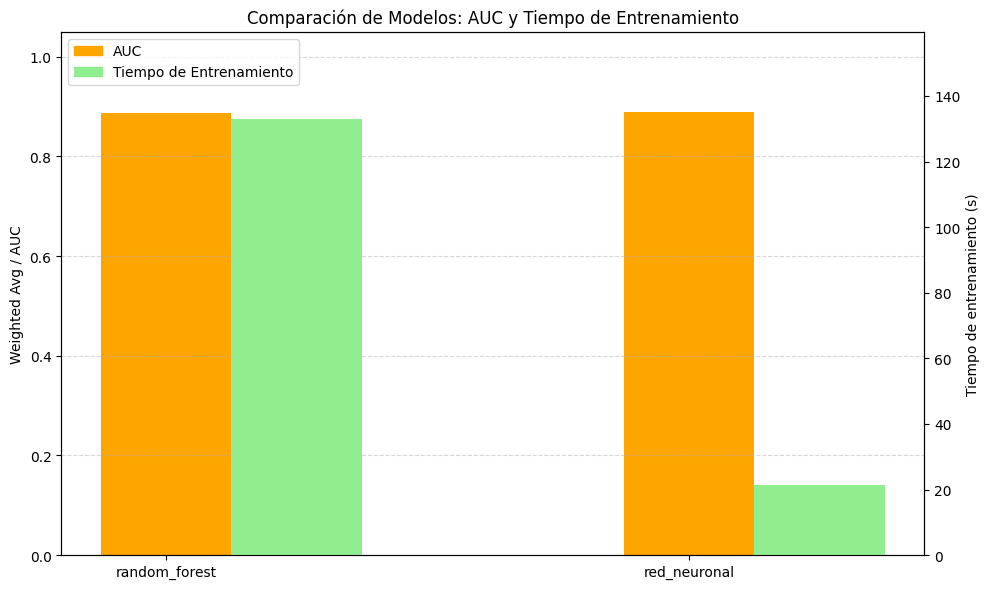

In [ ]:
# Convertir results en DataFrame
df = pd.DataFrame(results).T

# Posiciones y ancho de barras
x = np.arange(len(df))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras de precisión y AUC en eje Y1
bar2 = ax1.bar(x, df["auc"], width, color="orange", label="AUC")
ax1.set_ylabel("Weighted Avg / AUC")
ax1.set_ylim(0, 1.05)

# Barras de tiempo en eje Y2
ax2 = ax1.twinx()
bar3 = ax2.bar(x + width, df["train_time"], width, color="lightgreen", label="Tiempo de Entrenamiento")
ax2.set_ylabel("Tiempo de entrenamiento (s)")
ax2.set_ylim(0, df["train_time"].max() * 1.2)

# Eje X
ax1.set_xticks(x)
ax1.set_xticklabels(df.index)
plt.title("Comparación de Modelos: AUC y Tiempo de Entrenamiento")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Leyenda manual con parches de color
from matplotlib.patches import Patch
legend_patches = [
    Patch(color="orange", label="AUC"),
    Patch(color="lightgreen", label="Tiempo de Entrenamiento")
]
ax1.legend(handles=legend_patches, loc="upper left")

plt.tight_layout()
plt.show()


Dado este escenario, es importante considerar otras métricas, como la matriz de confusión, o priorizar según los objetivos del proyecto. En algunos casos, el tiempo de cómputo puede ser más relevante (por ejemplo, en sistemas en tiempo real), mientras que en otros, una mayor precisión podría ser crucial para minimizar errores o pérdidas.

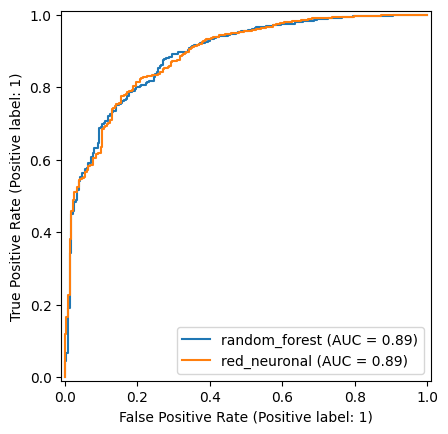

In [ ]:
fig, ax = plt.subplots()
for name, values in results.items():
    RocCurveDisplay.from_predictions(y_test, values['best'].predict_proba(X_test)[:,1],ax=ax,name=name)
plt.show()

En el caso de SVM, aunque presenta la mayor precisión (0.88), su AUC es muy bajo (0.50), lo que indica que no discrimina bien entre clases. Es decir, acierta en general, pero no distingue adecuadamente los casos positivos y negativos, lo que puede ser un problema en tareas sensibles. Además, su tiempo de entrenamiento es el más alto, lo que lo vuelve poco eficiente para este contexto.

## Guardar modelos

Para esta tarea utilizaremos joblib para guardar el modelo. Básicamente, estamos almacenando el objeto que representa al mejor modelo en Python, es decir, guardamos una instancia recuperable de python con toda su información en un archivo para poder reutilizarla luego sin necesidad de volver a entrenar.

In [ ]:
for name, values in results.items():
    dump(values['best'], f"/content/drive/MyDrive/IA_Aplicada/2026/IAA_Ayundatias_2026/IAA_ayun02_2026/models/model_{name}.joblib")